# UNIVERSIDAD NACIONAL DE LOJA
## INTEGRANTES;
 Roy Gordillo
 Arlette Quezada
 Andres Pinedad
 Dany Beltran
 Eduardo Soto


# APE_014_Logistica

## 1. Fundamentos e Implementación de la Función Sigmoide (Tarea 1)

### Replicar el entorno de simulación para predecir la Caída de un Servidor (0 o 1) en base a la Temperatura de la CPU.

Simulated Data Head:


,CPU_Temperature,Server_Failure
0,56.217808,1
1,96.550001,1
2,81.239576,1
3,71.906094,1
4,40.921305,0


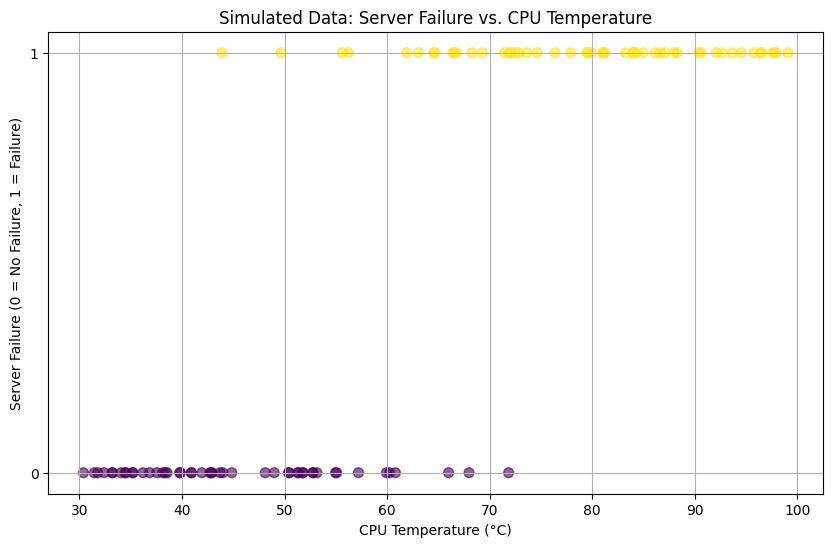

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Seed for reproducibility
np.random.seed(42)

# Simulate CPU Temperature (feature)
# Let's assume CPU temperature ranges from 30 to 100 degrees Celsius
cpu_temp = np.random.uniform(low=30, high=100, size=100).reshape(-1, 1)

# Simulate Server Failure (target) based on CPU Temperature
# We'll use a logistic function to generate probabilities, then convert to 0 or 1
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Parameters for the underlying logistic relationship (hypothetical)
# Higher temperature means higher probability of failure
# Let's make it more likely to fail at higher temperatures

# Adjusted coefficients to make the failure more distinct at higher temperatures
# slope: controls steepness, intercept: shifts the curve left/right
slope = 0.2
intercept = -12

# Calculate probabilities using the sigmoid function
probabilities = sigmoid(slope * cpu_temp + intercept)

# Generate server failure (0 or 1) based on probabilities
# Using a threshold of 0.5 for actual failure, but the model will learn this
server_failure = (probabilities > np.random.rand(100, 1)).astype(int)

# Create a DataFrame for better visualization (optional for this step, but good practice)
import pandas as pd
simulated_data = pd.DataFrame({'CPU_Temperature': cpu_temp.flatten(), 'Server_Failure': server_failure.flatten()})

print("Simulated Data Head:")
display(simulated_data.head())

# Visualize the simulated data
plt.figure(figsize=(10, 6))
plt.scatter(simulated_data['CPU_Temperature'], simulated_data['Server_Failure'],
            alpha=0.6, s=50, c=simulated_data['Server_Failure'], cmap='viridis')
plt.title('Simulated Data: Server Failure vs. CPU Temperature')
plt.xlabel('CPU Temperature (°C)')
plt.ylabel('Server Failure (0 = No Failure, 1 = Failure)')
plt.grid(True)
plt.yticks([0, 1])
plt.show()

### Ajustar el modelo logístico, visualizar la curva de probabilidad logística resultante e incluir la línea del umbral estándar del 50 por ciento.

Logistic Regression Coefficient: 0.0720
Logistic Regression Intercept: -4.1343


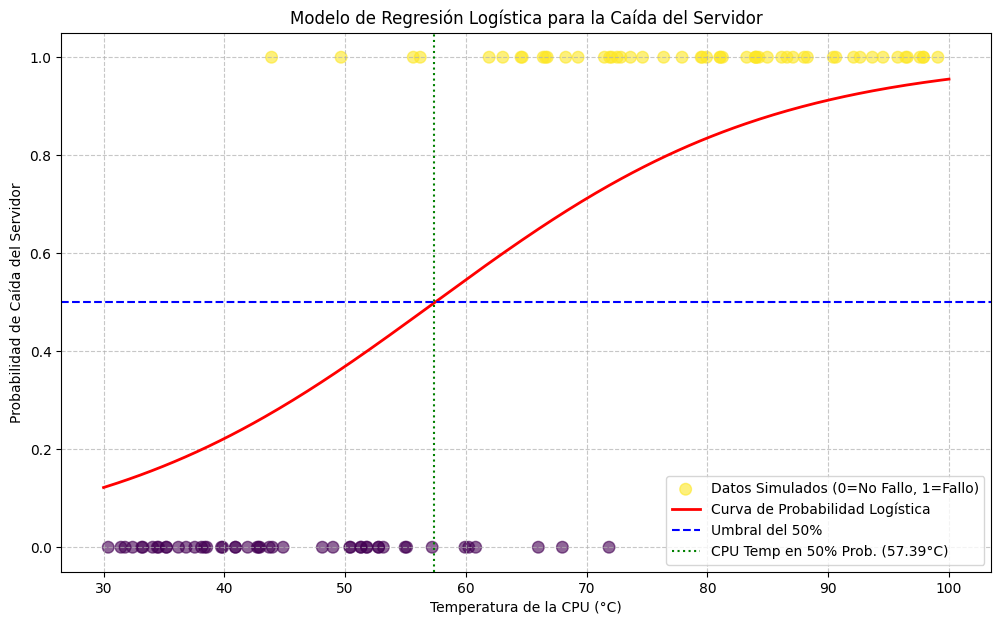

In [2]:
# Initialize and train the Logistic Regression model
model = LogisticRegression(solver='liblinear') # 'liblinear' is a good choice for small datasets
model.fit(cpu_temp, server_failure.ravel())

# Get the learned coefficients
coefficient = model.coef_[0][0]
intercept = model.intercept_[0]
print(f"Logistic Regression Coefficient: {coefficient:.4f}")
print(f"Logistic Regression Intercept: {intercept:.4f}")

# Generate a range of CPU temperatures for plotting the sigmoid curve
plot_cpu_temp = np.linspace(30, 100, 300).reshape(-1, 1)

# Predict probabilities using the trained model
predicted_probabilities = model.predict_proba(plot_cpu_temp)[:, 1] # Probability of class 1 (failure)

# Plot the simulated data, logistic regression curve, and 50% threshold
plt.figure(figsize=(12, 7))

# Scatter plot of simulated data
plt.scatter(simulated_data['CPU_Temperature'], simulated_data['Server_Failure'],
            alpha=0.6, s=70, c=simulated_data['Server_Failure'], cmap='viridis', label='Datos Simulados (0=No Fallo, 1=Fallo)')

# Plot the logistic probability curve
plt.plot(plot_cpu_temp, predicted_probabilities, color='red', linewidth=2, label='Curva de Probabilidad Logística')

# Add the 50% threshold line
plt.axhline(y=0.5, color='blue', linestyle='--', label='Umbral del 50%')

# Add lines to show where the 50% threshold crosses the CPU temperature
# Find the CPU temperature at which the probability is closest to 0.5
threshold_temp_idx = np.abs(predicted_probabilities - 0.5).argmin()
threshold_temp = plot_cpu_temp[threshold_temp_idx][0]
plt.axvline(x=threshold_temp, color='green', linestyle=':', label=f'CPU Temp en 50% Prob. ({threshold_temp:.2f}°C)')

plt.title('Modelo de Regresión Logística para la Caída del Servidor')
plt.xlabel('Temperatura de la CPU (°C)')
plt.ylabel('Probabilidad de Caída del Servidor')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.ylim(-0.05, 1.05) # Ensure y-axis covers full probability range
plt.show()

## 2. Ingeniería de Características y Predicción Regional (Tarea 2 - ABP)

### Cargar el dataset de su Proyecto Integrador empleando la librería pandas.

In [3]:
import pandas as pd

# Define the path to the dataset
dataset_path = '/content/Dataset_hogares_ambiental_2025.xlsx'

# Load the dataset
try:
    df = pd.read_excel(dataset_path)
    print(f"Dataset '{dataset_path}' cargado exitosamente. Las primeras 5 filas son:")
    display(df.head())
    print("\nInformación del DataFrame:")
    df.info()
except FileNotFoundError:
    print(f"Error: El archivo '{dataset_path}' no fue encontrado. Por favor, asegúrate de que el archivo esté en la ruta correcta.")
except Exception as e:
    print(f"Ocurrió un error al cargar el archivo: {e}")

Dataset '/content/Dataset_hogares_ambiental_2025.xlsx' cargado exitosamente. Las primeras 5 filas son:


,area,ciudad,conglomerado,panelm,vivienda,hogar,s101p11,s101p12a,s101p12b,s101p12c,...,s91p121,s91p122,s91p123,s91p124,s91p125,s91p126,s91p131,s91p132,s91p133,fexp
0,1,10150,3101,71,4,1,1,1,1,1,...,5,5,5,5,5,1,1,5,1,130.642361
1,1,10150,3801,74,3,1,1,1,1,1,...,5,3,3,5,5,1,3,2,4,73.698631
2,1,10150,3801,74,4,1,1,1,1,2,...,5,5,5,4,4,1,3,3,5,73.698631
3,1,10150,3801,74,5,1,1,1,1,1,...,5,5,3,5,5,1,2,3,5,73.698631
4,1,10150,3801,74,7,1,1,1,1,2,...,5,5,5,5,5,1,3,5,4,73.698631



Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8757 entries, 0 to 8756
Data columns (total 79 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area          8757 non-null   int64  
 1   ciudad        8757 non-null   int64  
 2   conglomerado  8757 non-null   int64  
 3   panelm        8757 non-null   int64  
 4   vivienda      8757 non-null   int64  
 5   hogar         8757 non-null   int64  
 6   s101p11       8757 non-null   int64  
 7   s101p12a      8757 non-null   int64  
 8   s101p12b      8757 non-null   int64  
 9   s101p12c      8757 non-null   int64  
 10  s101p12d      8757 non-null   int64  
 11  s101p12e      8757 non-null   int64  
 12  s101p2a       8757 non-null   int64  
 13  s101p2b       8757 non-null   int64  
 14  s101p2c       8757 non-null   int64  
 15  s101p2d       8757 non-null   int64  
 16  s101p2e       8757 non-null   int64  
 17  s101p2f       8757 non-null   int64  
 18  

### Binarización: Seleccionar una variable continua de interés y transformarla en una variable binaria (por ejemplo, asignando el valor 1 si el registro supera el promedio, y el valor 0 de lo contrario).

In [5]:
# Select a continuous variable for binarization, e.g., 'fexp'
continuous_var_to_binarize = 'fexp'

# Calculate the mean of the selected continuous variable
mean_value = df[continuous_var_to_binarize].mean()
print(f"Mean of '{continuous_var_to_binarize}': {mean_value:.2f}")

# Create the binary target variable
# Assign 1 if the record exceeds the average, and 0 otherwise
df['target_binary'] = (df[continuous_var_to_binarize] > mean_value).astype(int)

print(f"\nNew binary target variable 'target_binary' created based on '{continuous_var_to_binarize}'.")
print("Value counts for 'target_binary':")
display(df['target_binary'].value_counts())
print("\nFirst 5 rows with new target variable:")
display(df[[continuous_var_to_binarize, 'target_binary']].head())

Mean of 'fexp': 598.12

New binary target variable 'target_binary' created based on 'fexp'.
Value counts for 'target_binary':


,count
target_binary,
0,6466
1,2291



First 5 rows with new target variable:


,fexp,target_binary
0,130.642361,0
1,73.698631,0
2,73.698631,0
3,73.698631,0
4,73.698631,0


### Seleccionar al menos dos variables predictoras continuas, entrenar el modelo logístico e interpretar los signos de los coeficientes obtenidos y sus valores-p parciales para comprobar la significancia.

In [6]:
import statsmodels.api as sm

# Select predictor variables (assuming 's91p121' and 's91p122' are treated as continuous-like)
predictor_vars = ['s91p121', 's91p122']

X = df[predictor_vars]
y = df['target_binary']

# Add a constant to the independent variables for statsmodels (for intercept)
X = sm.add_constant(X)

# Train the logistic regression model using statsmodels
logit_model = sm.Logit(y, X)
result = logit_model.fit()

# Print the model summary
print("\nLogistic Regression Model Summary:")
print(result.summary())

# Interpret coefficients and p-values
print("\nInterpretación de Coeficientes y Valores-P:")
for var, coef, p_val in zip(X.columns, result.params, result.pvalues):
    if var == 'const':
        print(f"  Intercepto (constante): {coef:.4f} (p-valor: {p_val:.4f})")
        print("    - Representa el log-odds de la variable objetivo cuando todas las variables predictoras son cero.")
    else:
        print(f"  Variable Predictora '{var}': Coeficiente = {coef:.4f} (p-valor: {p_val:.4f})")
        print(f"    - Un coeficiente positivo ({coef:.4f} > 0) indica que a medida que '{var}' aumenta, el log-odds de que la variable objetivo sea 1 también aumenta (mayor probabilidad de 1).")
        print(f"    - Un coeficiente negativo ({coef:.4f} < 0) indica que a medida que '{var}' aumenta, el log-odds de que la variable objetivo sea 1 disminuye (menor probabilidad de 1).")
        if p_val < 0.05:
            print(f"    - El p-valor ({p_val:.4f}) es menor a 0.05, por lo tanto, '{var}' es estadísticamente significativo en la predicción de la variable objetivo.")
        else:
            print(f"    - El p-valor ({p_val:.4f}) es mayor o igual a 0.05, por lo tanto, '{var}' no es estadísticamente significativo en la predicción de la variable objetivo al nivel de significancia del 5%.")

Optimization terminated successfully.
         Current function value: 0.574675
         Iterations 5

Logistic Regression Model Summary:
                           Logit Regression Results                           
Dep. Variable:          target_binary   No. Observations:                 8757
Model:                          Logit   Df Residuals:                     8754
Method:                           MLE   Df Model:                            2
Date:                Tue, 21 Jul 2026   Pseudo R-squ.:               0.0001189
Time:                        17:16:05   Log-Likelihood:                -5032.4
converged:                       True   LL-Null:                       -5033.0
Covariance Type:            nonrobust   LLR p-value:                    0.5496
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.0188      0.032    -31.696      0.000      -1.082      

## 3. Matriz de Confusión y Evaluación (Tarea 3)

### Utilizar scikit-learn para extraer las predicciones de clase basándose en el umbral inicial de 0.50.

In [9]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# --- Predictions for Simulated Data (Task 1) ---
# The 'model' (sklearn LogisticRegression) is already trained on cpu_temp and server_failure
# The predict method uses a default threshold of 0.5
simulated_predictions = model.predict(cpu_temp)

print("Predicciones para el modelo de datos simulados (Umbral 0.50) realizadas.")

# --- Predictions for Integrator Project Data (Task 2) ---
# The 'result' (statsmodels Logit model) holds the trained model
# We need to get probabilities first, then apply the 0.50 threshold
project_probabilities = result.predict(X) # X includes the constant
project_predictions = (project_probabilities > 0.5).astype(int)

print("Predicciones para el modelo del Proyecto Integrador (Umbral 0.50) realizadas.")

Predicciones para el modelo de datos simulados (Umbral 0.50) realizadas.
Predicciones para el modelo del Proyecto Integrador (Umbral 0.50) realizadas.


### Desplegar visualmente la Matriz de Confusión tanto para los datos simulados como para el modelo de su Proyecto Integrador, calculando adicionalmente la métrica de Exactitud Global (Accuracy).


Exactitud Global (Accuracy) para Datos Simulados: 0.9000
Exactitud Global (Accuracy) para Datos del Proyecto Integrador: 0.7384


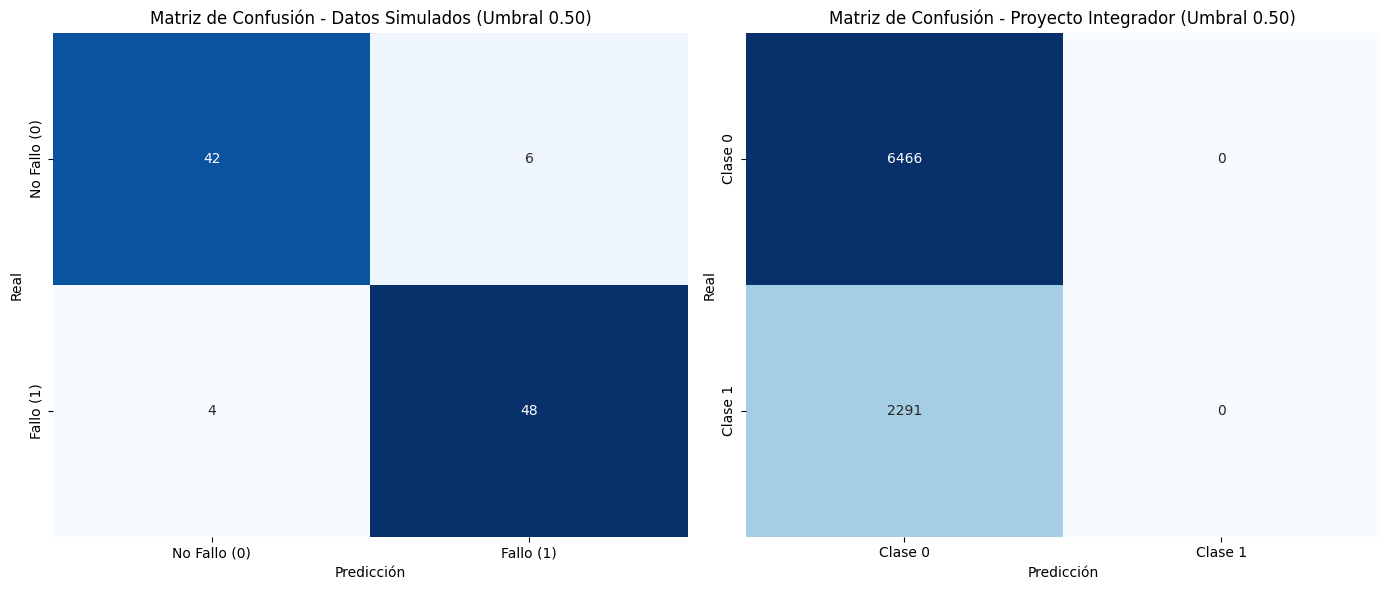

In [10]:
plt.figure(figsize=(14, 6))

# --- Simulated Data Confusion Matrix and Accuracy ---
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
cm_simulated = confusion_matrix(server_failure, simulated_predictions)
sns.heatmap(cm_simulated, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Fallo (0)', 'Fallo (1)'],
            yticklabels=['No Fallo (0)', 'Fallo (1)'])
plt.title('Matriz de Confusión - Datos Simulados (Umbral 0.50)')
plt.xlabel('Predicción')
plt.ylabel('Real')
accuracy_simulated = accuracy_score(server_failure, simulated_predictions)
print(f"\nExactitud Global (Accuracy) para Datos Simulados: {accuracy_simulated:.4f}")

# --- Integrator Project Data Confusion Matrix and Accuracy ---
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
cm_project = confusion_matrix(y, project_predictions)
sns.heatmap(cm_project, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Clase 0', 'Clase 1'],
            yticklabels=['Clase 0', 'Clase 1'])
plt.title('Matriz de Confusión - Proyecto Integrador (Umbral 0.50)')
plt.xlabel('Predicción')
plt.ylabel('Real')
accuracy_project = accuracy_score(y, project_predictions)
print(f"Exactitud Global (Accuracy) para Datos del Proyecto Integrador: {accuracy_project:.4f}")

plt.tight_layout()
plt.show()